# 🛒 Shopper Spectrum: Customer Segmentation & Product Recommendations
**Domain:** E-Commerce and Retail Analytics  
**Techniques:** RFM Analysis, KMeans Clustering, Collaborative Filtering  
**Deliverable:** Jupyter Notebook + Streamlit App

## Step 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('online_retail.csv', encoding='utf-8', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print('Shape:', df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 2: Data Understanding

In [2]:
print('=== Dataset Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

=== Missing Values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Basic Statistics ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2023-07-04 13:34:57.156387072,4.611114,15287.690570
min,-80995.000000,2022-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2023-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2023-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2023-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2023-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [3]:
print('Date Range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
print('Unique Customers:', df['CustomerID'].nunique())
print('Unique Products:', df['Description'].nunique())
print('Unique Countries:', df['Country'].nunique())
print('Cancelled Invoices:', df['InvoiceNo'].astype(str).str.startswith('C').sum())

Date Range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00
Unique Customers: 4372
Unique Products: 4223
Unique Countries: 38
Cancelled Invoices: 9288


## Step 3: Data Preprocessing & Cleaning

In [4]:
print('Before cleaning:', df.shape)

# 1. Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
print('After dropping missing CustomerID:', df.shape)

# 2. Remove cancelled invoices (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print('After removing cancellations:', df.shape)

# 3. Remove negative or zero quantities
df = df[df['Quantity'] > 0]
print('After removing invalid quantity:', df.shape)

# 4. Remove zero or negative unit prices
df = df[df['UnitPrice'] > 0]
print('After removing invalid prices:', df.shape)

# 5. Remove rows with missing Description
df = df.dropna(subset=['Description'])
print('After dropping missing Description:', df.shape)

# 6. Fix data types
df['CustomerID'] = df['CustomerID'].astype(int)
df['Description'] = df['Description'].str.strip().str.upper()

# 7. Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print()
print('=== Clean Dataset ===' )
df.head()

Before cleaning: (541909, 8)
After dropping missing CustomerID: (406829, 8)
After removing cancellations: (397924, 8)
After removing invalid quantity: (397924, 8)
After removing invalid prices: (397884, 8)
After dropping missing Description: (397884, 8)

=== Clean Dataset ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Step 4: Exploratory Data Analysis (EDA)

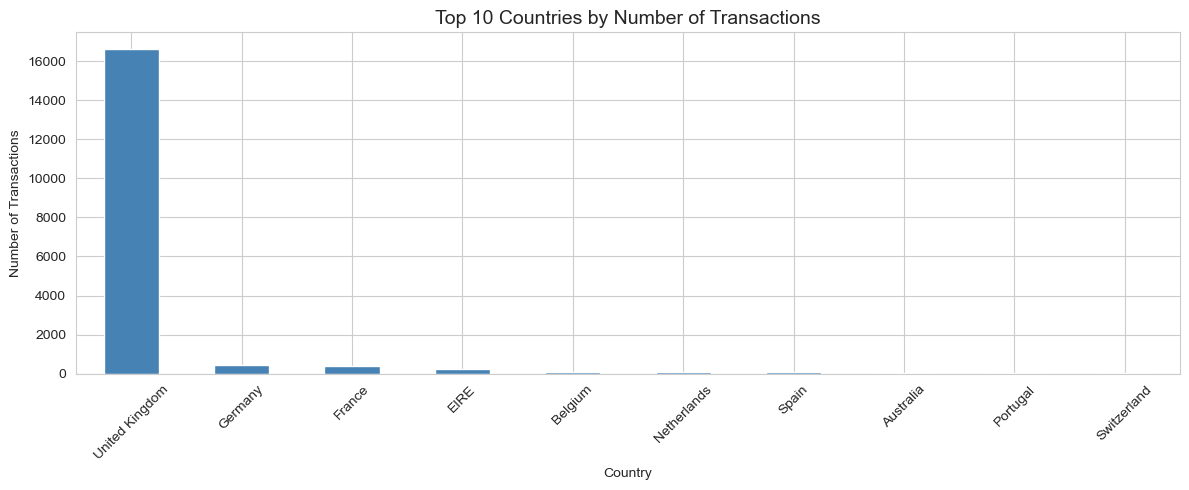

In [5]:
# 4.1 Transaction Volume by Country (Top 10)
country_counts = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
country_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Countries by Number of Transactions', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

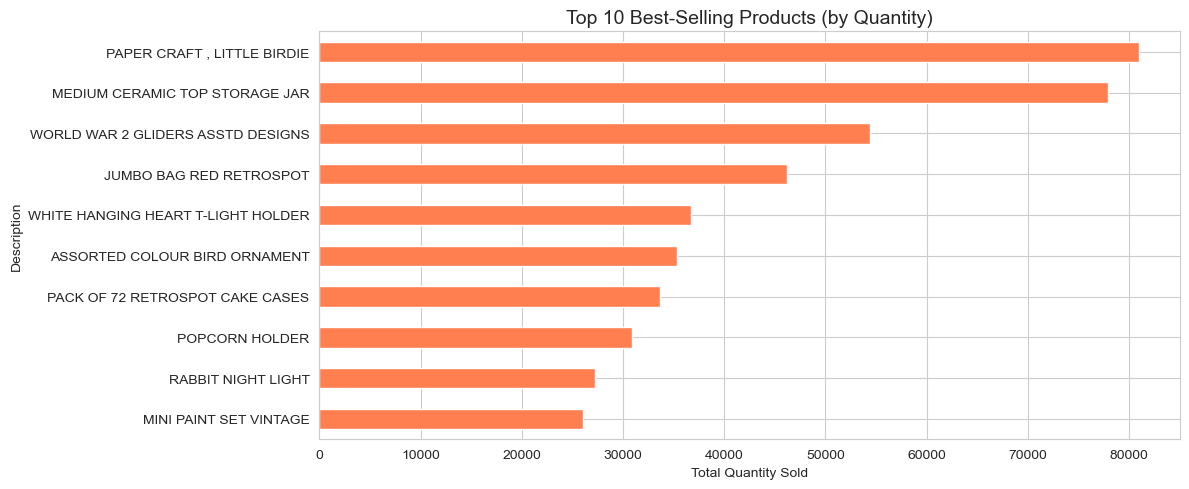

In [6]:
# 4.2 Top 10 Best-Selling Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_products.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Top 10 Best-Selling Products (by Quantity)', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

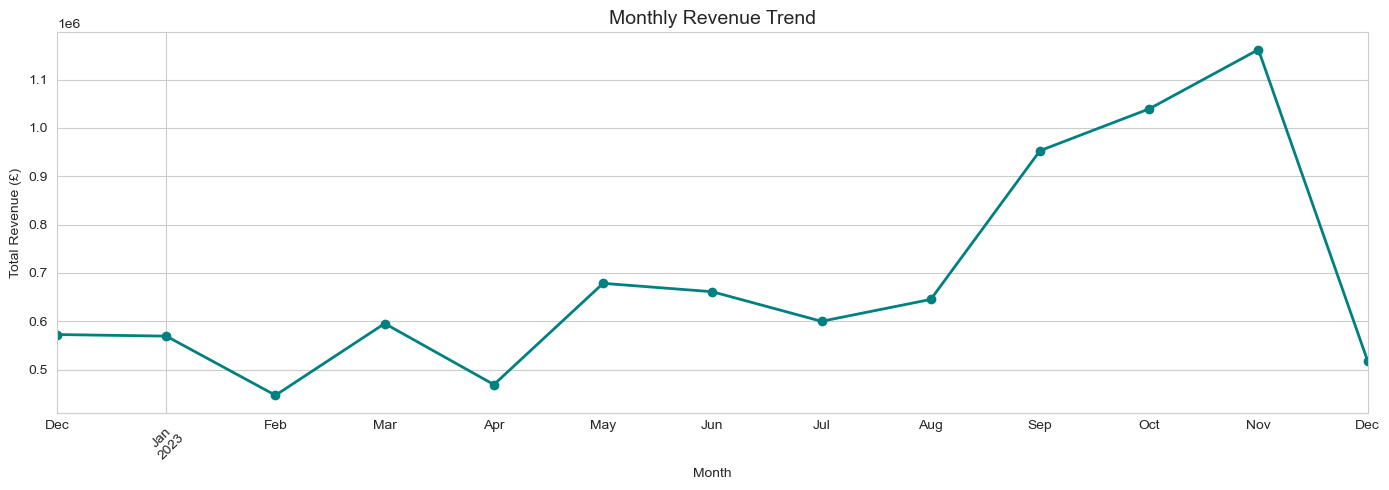

In [7]:
# 4.3 Purchase Trends Over Time (Monthly Revenue)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

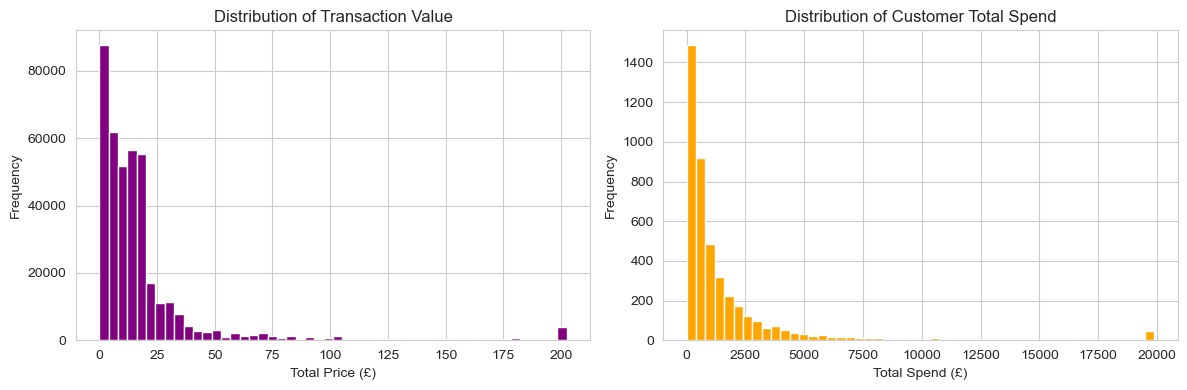

In [8]:
# 4.4 Monetary Distribution per Transaction
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['TotalPrice'].clip(upper=df['TotalPrice'].quantile(0.99)).hist(bins=50, color='purple', edgecolor='white')
plt.title('Distribution of Transaction Value')
plt.xlabel('Total Price (£)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
customer_spend = df.groupby('CustomerID')['TotalPrice'].sum()
customer_spend.clip(upper=customer_spend.quantile(0.99)).hist(bins=50, color='orange', edgecolor='white')
plt.title('Distribution of Customer Total Spend')
plt.xlabel('Total Spend (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Step 5: RFM Feature Engineering

In [9]:
# Reference date = 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Reference Date:', reference_date)

# Calculate RFM
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print('RFM Shape:', rfm.shape)
rfm.head(10)

Reference Date: 2023-12-10 12:50:00
RFM Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


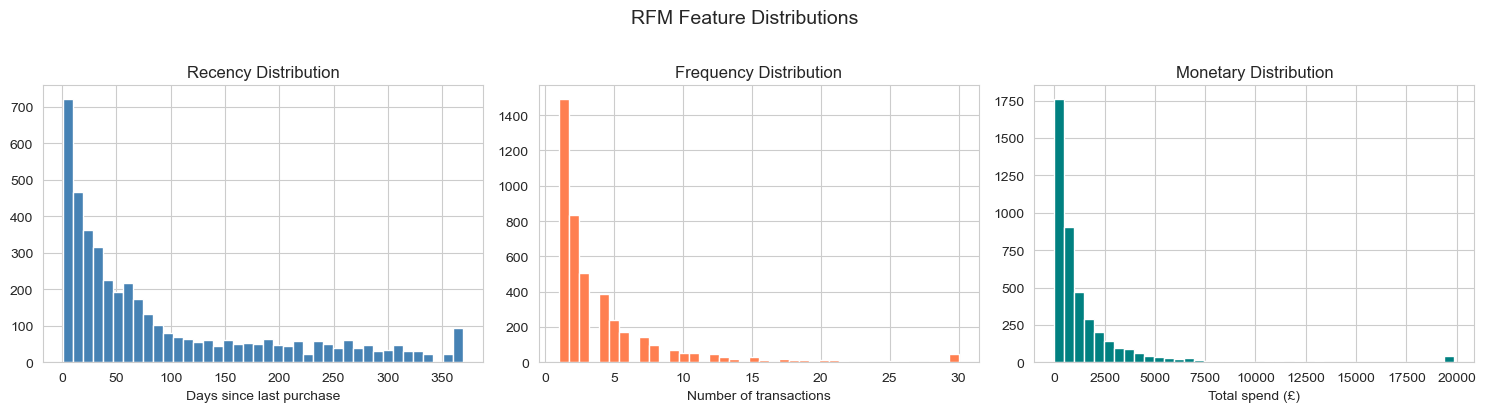

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [10]:
# RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].clip(upper=rfm['Recency'].quantile(0.99)).hist(ax=axes[0], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.99)).hist(ax=axes[1], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of transactions')

rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)).hist(ax=axes[2], bins=40, color='teal', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (£)')

plt.suptitle('RFM Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(rfm[['Recency','Frequency','Monetary']].describe())

## Step 6: Clustering — KMeans on RFM

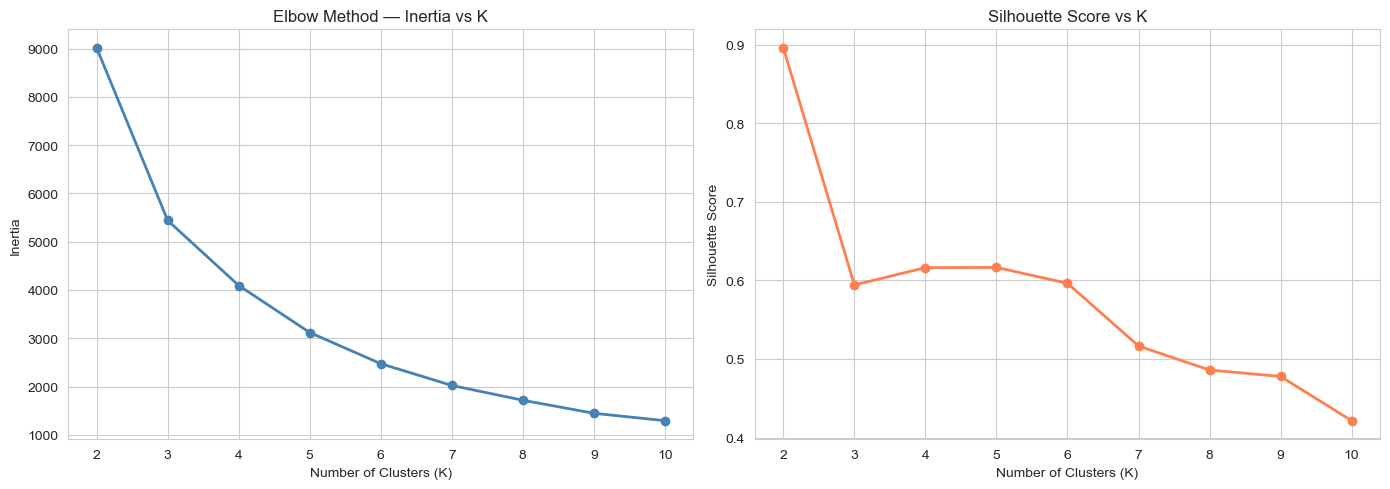

Best K by Silhouette Score: 2


In [11]:
# Normalize RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'Best K by Silhouette Score: {best_k}')

In [12]:
# Final KMeans with best K (adjust if needed)
BEST_K = 4  # Change based on elbow/silhouette

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster Profiles
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print('=== Cluster RFM Averages ===')
print(cluster_summary)

=== Cluster RFM Averages ===
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


In [13]:
# Label clusters based on RFM averages
# Inspect cluster_summary above and assign labels accordingly
# Example logic (adjust after inspecting your output):
cluster_labels = {}
for cluster_id, row in cluster_summary.iterrows():
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if r < cluster_summary['Recency'].median() and f > cluster_summary['Frequency'].median():
        cluster_labels[cluster_id] = 'High-Value'
    elif r < cluster_summary['Recency'].median():
        cluster_labels[cluster_id] = 'Regular'
    elif f < cluster_summary['Frequency'].median() and m < cluster_summary['Monetary'].median():
        cluster_labels[cluster_id] = 'Occasional'
    else:
        cluster_labels[cluster_id] = 'At-Risk'

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print('Segment Distribution:')
print(rfm['Segment'].value_counts())

Segment Distribution:
Segment
Occasional    4121
High-Value     217
Name: count, dtype: int64


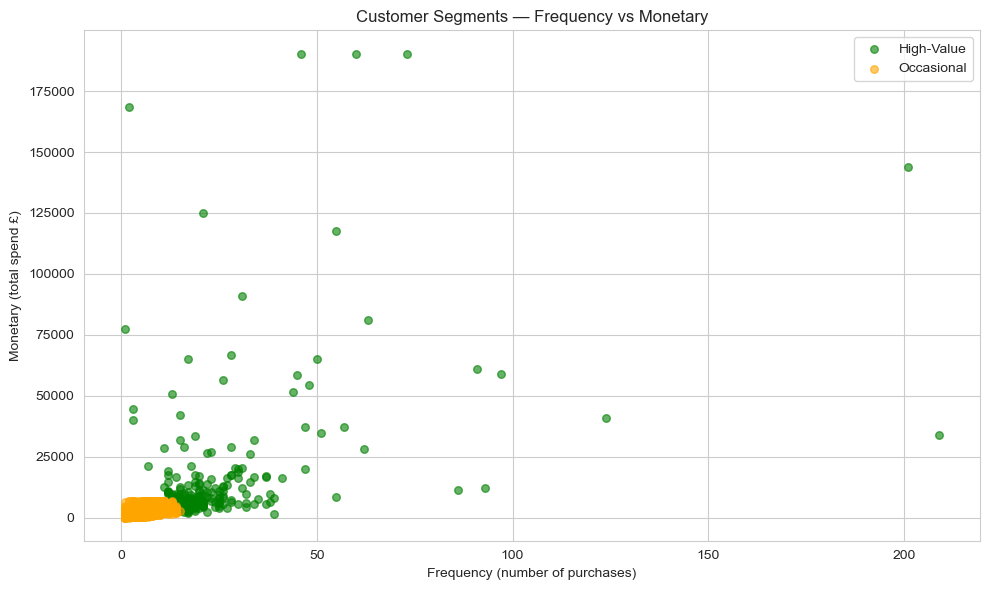

In [14]:
# Visualize Clusters — 2D scatter (Frequency vs Monetary)
colors = {'High-Value': 'green', 'Regular': 'steelblue', 'Occasional': 'orange', 'At-Risk': 'red'}

plt.figure(figsize=(10, 6))
for seg, grp in rfm.groupby('Segment'):
    plt.scatter(grp['Frequency'], grp['Monetary'].clip(upper=grp['Monetary'].quantile(0.99)),
                label=seg, alpha=0.6, s=30, color=colors.get(seg, 'gray'))
plt.title('Customer Segments — Frequency vs Monetary')
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Monetary (total spend £)')
plt.legend()
plt.tight_layout()
plt.show()

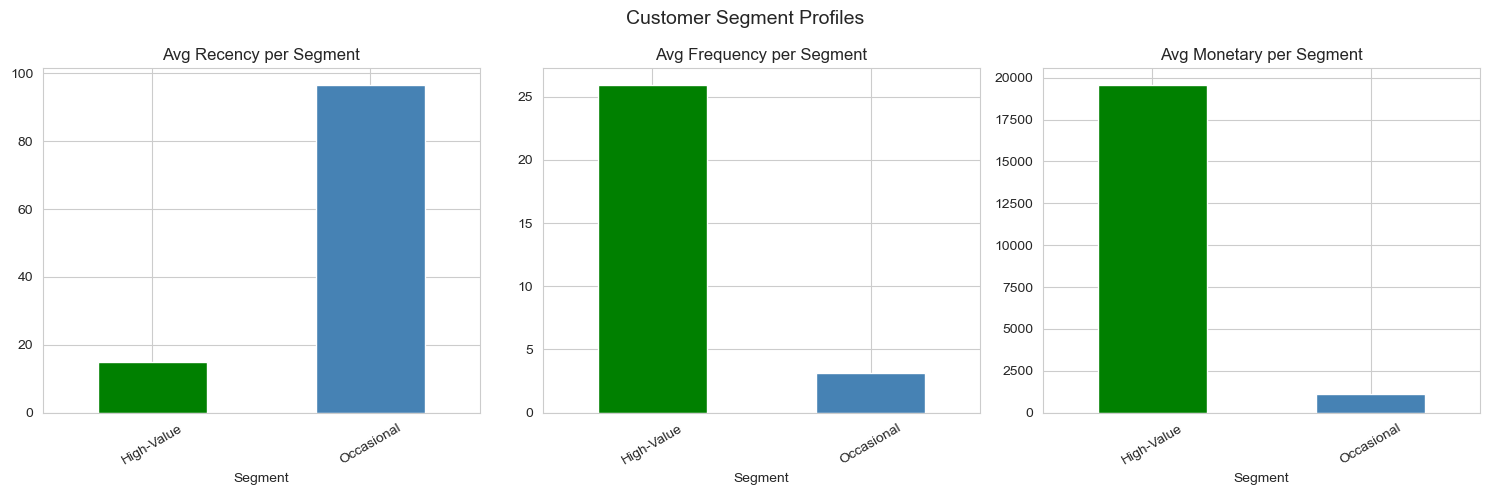

In [15]:
# Cluster profile bar chart
cluster_summary_labeled = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    cluster_summary_labeled[col].plot(kind='bar', ax=ax, color=['green','steelblue','orange','red'][:len(cluster_summary_labeled)], edgecolor='white')
    ax.set_title(f'Avg {col} per Segment')
    ax.set_xlabel('Segment')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Customer Segment Profiles', fontsize=14)
plt.tight_layout()
plt.show()

## Step 7: Product Recommendation — Item-Based Collaborative Filtering

In [16]:
# Build Customer-Product pivot matrix
pivot = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack(fill_value=0)
print('Pivot shape (Customers x Products):', pivot.shape)
pivot.head()

Pivot shape (Customers x Products): (4338, 3866)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# Compute item-item cosine similarity
# Transpose so products are rows
item_similarity = cosine_similarity(pivot.T)
item_sim_df = pd.DataFrame(item_similarity, index=pivot.columns, columns=pivot.columns)
print('Item similarity matrix shape:', item_sim_df.shape)

Item similarity matrix shape: (3866, 3866)


In [18]:
# Recommendation function
def get_recommendations(product_name, n=5):
    product_name = product_name.strip().upper()
    if product_name not in item_sim_df.index:
        return f"Product '{product_name}' not found in dataset."
    similar = item_sim_df[product_name].drop(product_name).sort_values(ascending=False).head(n)
    return similar

# Test it
test_product = pivot.columns[0]
print(f'Top 5 products similar to: {test_product}')
print(get_recommendations(test_product))

Top 5 products similar to: 10 COLOUR SPACEBOY PEN
Description
I LOVE LONDON MINI RUCKSACK        0.845303
SET 12 COLOURING PENCILS DOILEY    0.845303
SET 36 COLOURING PENCILS DOILEY    0.845303
PLASTERS IN TIN SPACEBOY           0.844628
BLUE BUNNY EASTER EGG BASKET       0.842363
Name: 10 COLOUR SPACEBOY PEN, dtype: float64


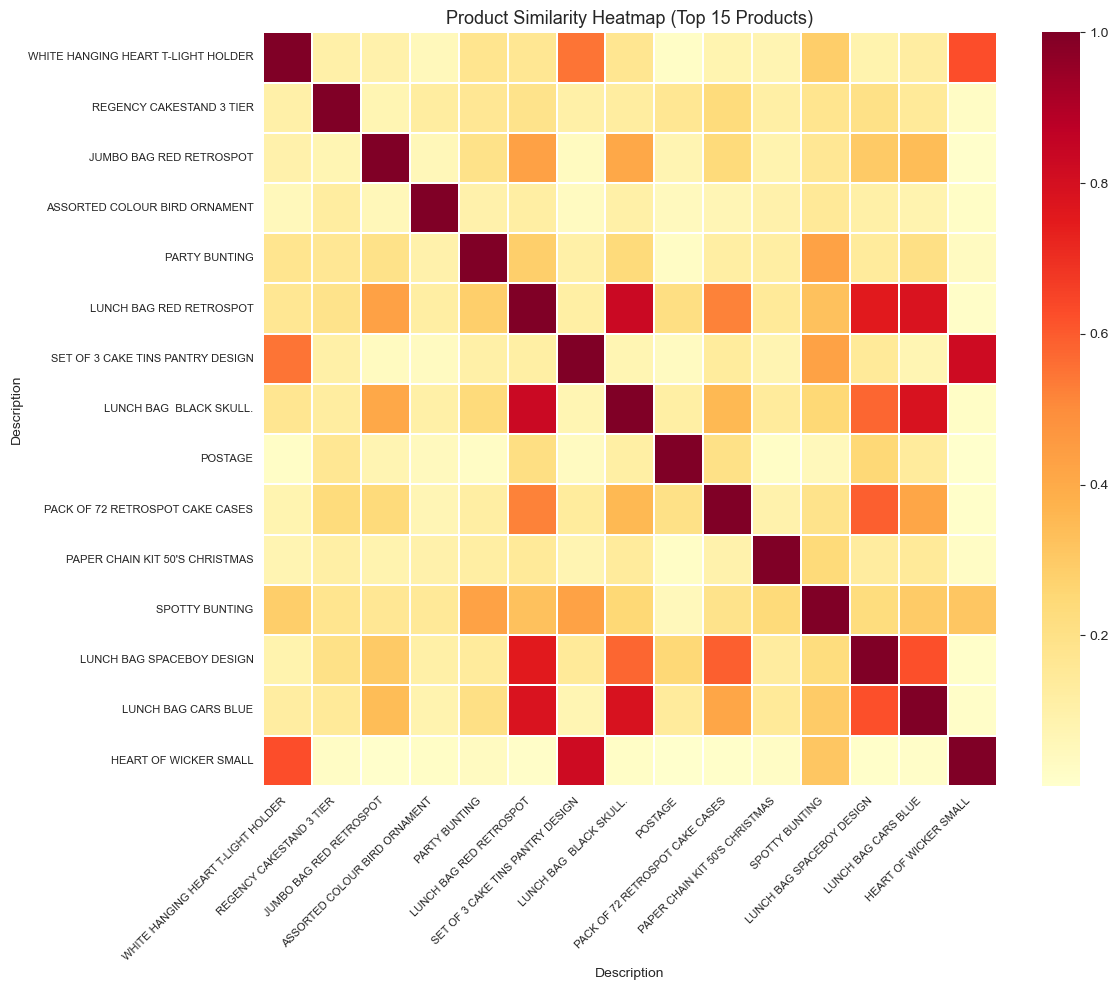

In [19]:
# Recommendation Heatmap (top 15 products)
top15 = df['Description'].value_counts().head(15).index.tolist()
heatmap_data = item_sim_df.loc[top15, top15]

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=False, cmap='YlOrRd', linewidths=0.3)
plt.title('Product Similarity Heatmap (Top 15 Products)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Step 8: Save Models for Streamlit

In [20]:
# Save KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save cluster labels mapping
with open('cluster_labels.pkl', 'wb') as f:
    pickle.dump(cluster_labels, f)

# Save item similarity dataframe
item_sim_df.to_pickle('item_similarity.pkl')

# Save product list
product_list = list(pivot.columns)
with open('product_list.pkl', 'wb') as f:
    pickle.dump(product_list, f)

print('All models saved!')
print('Files: kmeans_model.pkl, scaler.pkl, cluster_labels.pkl, item_similarity.pkl, product_list.pkl')

All models saved!
Files: kmeans_model.pkl, scaler.pkl, cluster_labels.pkl, item_similarity.pkl, product_list.pkl


## Step 9: Model Evaluation


In [21]:
# Clustering Evaluation
final_sil = silhouette_score(rfm_scaled, rfm['Cluster'])
final_inertia = kmeans.inertia_

print('=== Clustering Evaluation ===')
print(f'Number of Clusters : {BEST_K}')
print(f'Silhouette Score   : {final_sil:.4f}  (closer to 1.0 is better)')
print(f'Inertia            : {final_inertia:.2f}  (lower is better)')
print()
print('=== Segment Summary ===')
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].agg(['mean','count']).round(2))

=== Clustering Evaluation ===
Number of Clusters : 4
Silhouette Score   : 0.6162  (closer to 1.0 is better)
Inertia            : 4092.14  (lower is better)

=== Segment Summary ===
           Recency       Frequency        Monetary      
              mean count      mean count      mean count
Segment                                                 
High-Value   15.01   217     25.94   217  19576.28   217
Occasional   96.62  4121      3.13  4121   1131.61  4121
